# 03 — Определение типа кузова автомобиля
### Практическая часть дипломной работы

**Задачи:**
1. EDA датасета типов кузова
2. Fine-tuning ResNet18 (6 классов)
3. Оценка: Accuracy top-1/3, Confusion Matrix, F1 per class
4. Сравнение архитектур: ResNet18 vs MobileNetV2

**Классы:** sedan · suv · hatchback · van · truck · minibus

**Датасет:** CompCars body type annotations  
https://mmlab.ie.cuhk.edu.hk/datasets/comp_cars/

**Выход:** `body_resnet18.pth` → Google Drive

---
> **Предыдущий:** `02_color_classifier.ipynb` | **Следующий:** `04_pipeline_final.ipynb`

In [2]:
%%capture
!pip install -q torch torchvision Pillow matplotlib seaborn scikit-learn pandas tqdm


In [3]:
import json, time, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import (
    resnet18, ResNet18_Weights,
    mobilenet_v2, MobileNet_V2_Weights
)
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, top_k_accuracy_score
)
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
try:
    from google.colab import output as _colab_out; IN_COLAB = True
except ImportError:
    IN_COLAB = False

EPOCHS       = 40
BATCH_SIZE   = 32
LR           = 1e-3
UNFREEZE_AT  = 6
PATIENCE     = 7     # early stopping: остановка после N эпох без улучшения
WEIGHT_DECAY = 3e-4  # L2-регуляризация

BODY_LABELS = ['sedan', 'suv', 'hatchback', 'van', 'truck', 'minibus']

WORK_DIR   = Path('diploma_03_body')
DATA_DIR   = WORK_DIR / 'data' / 'body'
OUTPUT_DIR = WORK_DIR / 'output'
MODELS_DIR = WORK_DIR / 'models'
for d in [DATA_DIR, OUTPUT_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)


print(f'Device: {DEVICE}  |  Epochs: {EPOCHS}')


Device: cuda  |  Epochs: 40


In [4]:
# ── Google Drive ──────────────────────────────────────────────────────────────
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_MODELS = Path('/content/drive/MyDrive/diploma/models')
else:
    DRIVE_MODELS = MODELS_DIR
DRIVE_MODELS.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = DRIVE_MODELS / 'body_resnet18.pth'
print(f'Модель: {MODEL_SAVE_PATH}')

Mounted at /content/drive
Модель: /content/drive/MyDrive/diploma/models/body_resnet18.pth


## 1. Подготовка датасета

### CompCars — маппинг классов

| CompCars (оригинал) | Наш класс |
|---|---|
| sedan, fastback, convertible | sedan |
| hatchback, estate | hatchback |
| SUV, crossover | suv |
| MPV | van |
| pickup, truck | truck |
| microbus, minibus | minibus |

### Ожидаемая структура:
```
diploma_03_body/data/body/
    train/  sedan/  suv/  hatchback/  van/  truck/  minibus/
    val/    ...
```

In [5]:
# ── Подготовка датасета CompCars ───────────────────────────────────────────
#
#  Архив (~12 ГБ) скачивается во временный /tmp Colab — на Drive НЕ занимает место.
#  На Drive сохраняется только готовый датасет (≈ MAX_PER_CLASS × 6 классов × ~50 КБ).
#
#  MAX_PER_CLASS = 1000 → ~300 МБ на Drive
#  MAX_PER_CLASS = 500  → ~150 МБ на Drive
#
# ──────────────────────────────────────────────────────────────────────────

COMPCARS_GDRIVE_ID   = '18EunmjOJsbE5Lh9zA0cZ4wKV6Um46dkg'
COMPCARS_ARCHIVE_PWD = 'd89551fd190e38'
VAL_SPLIT      = 0.15
MAX_PER_CLASS  = 1000   # ← уменьшите, если нужно меньше места (500 тоже ок)

# Куда класть готовый датасет (папка на Drive — сохраняется между сессиями)
DATASET_DRIVE_DIR = '/content/drive/MyDrive/diploma/data/body_v2'  # v2: чистый маппинг sedan

# Маппинг type_id из attributes.txt → наш класс
_TYPE_MAP = {
    1: 'van',       # MPV
    2: 'suv',       # SUV
    3: 'sedan',     # sedan
    4: 'hatchback', # hatchback
    5: 'minibus',   # minibus
    6: 'sedan',     # fastback → sedan (силуэтом близок к седану — оставляем)
    7: 'hatchback', # estate   → hatchback
    8: 'truck',     # pickup   → truck
    10: 'suv',      # crossover → suv
    # 9 (sports) и 11 (convertible) ИСКЛЮЧЕНЫ: визуально не седаны,
    # размывали класс sedan и роняли precision (0.635). Чистим класс.
}

import shutil, random, subprocess
from pathlib import Path

# Монтирование Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('Google Drive смонтирован')
except Exception:
    print('Не Colab — Google Drive не монтируется')

dataset_drive = Path(DATASET_DRIVE_DIR)

# ── Если датасет уже подготовлен на Drive — просто переключаем DATA_DIR ───
if (dataset_drive / 'train').exists() and any((dataset_drive / 'train').iterdir()):
    print(f'Датасет найден на Drive: {dataset_drive}')
    DATA_DIR = dataset_drive  # переназначаем переменную
    print(f'DATA_DIR → {DATA_DIR}')
else:
    # ── Скачивание архива во /tmp (НЕ на Drive) ───────────────────────────
    tmp_raw     = Path('/tmp/compcars_raw')
    extract_dir = Path('/tmp/compcars')

    if not (extract_dir / 'data' / 'image').exists():
        tmp_raw.mkdir(exist_ok=True)
        extract_dir.mkdir(exist_ok=True)

        print('Скачивание архива CompCars в /tmp (~12 ГБ, 10-20 мин)...')
        subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
        result = subprocess.run(
            ['gdown', '--folder', COMPCARS_GDRIVE_ID, '-O', str(tmp_raw), '--remaining-ok'],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            print('gdown вывод:', result.stderr[-1000:])
            raise RuntimeError(
                '\n\nНе удалось скачать. Скачайте вручную:\n'
                f'  https://drive.google.com/open?id={COMPCARS_GDRIVE_ID}\n'
                'и загрузите архивы data.zip + data.z01..data.z22 в /tmp/compcars_raw/'
            )
        print('Скачивание завершено')

        combined = '/tmp/compcars_combined.zip'
        print('Объединение split-zip архивов...')
        subprocess.run(['zip', '-F', str(tmp_raw / 'data.zip'), '--out', combined], check=True)
        print('Распаковка (5-10 мин)...')
        subprocess.run(['unzip', '-P', COMPCARS_ARCHIVE_PWD, '-q', combined, '-d', str(extract_dir)], check=True)
        Path(combined).unlink(missing_ok=True)
        shutil.rmtree(tmp_raw, ignore_errors=True)
        print('Распаковка завершена, архивы удалены из /tmp')
    else:
        print('Архив уже распакован, пропускаем')

    # ── Чтение атрибутов: model_id → класс ───────────────────────────────
    attr_path = extract_dir / 'data' / 'misc' / 'attributes.txt'

    model_class = {}
    with open(attr_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts or not parts[0].isdigit():
                continue
            if len(parts) >= 6:
                model_id = int(parts[0])
                type_id  = int(parts[5])
                label    = _TYPE_MAP.get(type_id)
                if label:
                    model_class[model_id] = label

    print(f'Распознано моделей с меткой: {len(model_class)}')

    # ── Сбор путей к изображениям ─────────────────────────────────────────
    image_root = extract_dir / 'data' / 'image'
    by_class   = {lbl: [] for lbl in set(_TYPE_MAP.values())}

    for make_dir in sorted(image_root.iterdir()):
        if not make_dir.is_dir(): continue
        for model_dir in sorted(make_dir.iterdir()):
            if not model_dir.is_dir(): continue
            try:    model_id = int(model_dir.name)
            except ValueError: continue
            label = model_class.get(model_id)
            if label is None: continue
            for img in model_dir.rglob('*.jpg'):
                by_class[label].append(img)

    total = sum(len(v) for v in by_class.values())
    print(f'Всего изображений: {total}')
    for lbl, imgs in sorted(by_class.items()):
        print(f'  {lbl:12s}: {len(imgs)}')

    # ── Ограничение и разбивка train/val ──────────────────────────────────
    random.seed(42)
    all_samples = []
    for label, imgs in by_class.items():
        random.shuffle(imgs)
        for img in imgs[:MAX_PER_CLASS]:
            all_samples.append((img, label))

    random.shuffle(all_samples)
    n_val         = int(len(all_samples) * VAL_SPLIT)
    val_samples   = all_samples[:n_val]
    train_samples = all_samples[n_val:]
    print(f'\nПосле ограничения {MAX_PER_CLASS}/класс:')
    print(f'  Train: {len(train_samples)}  Val: {len(val_samples)}')

    # ── Копирование на Drive ───────────────────────────────────────────────
    dataset_drive.mkdir(parents=True, exist_ok=True)
    for split_name, samples in [('train', train_samples), ('val', val_samples)]:
        for img_path, label in samples:
            rel_parts   = img_path.relative_to(image_root).parts
            unique_name = '_'.join(rel_parts)
            dest = dataset_drive / split_name / label / unique_name
            dest.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img_path, dest)

    DATA_DIR = dataset_drive  # переназначаем переменную
    print(f'Датасет сохранён на Drive: {dataset_drive}')
    print(f'DATA_DIR → {DATA_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive смонтирован
Датасет найден на Drive: /content/drive/MyDrive/diploma/data/body_v2
DATA_DIR → /content/drive/MyDrive/diploma/data/body_v2


In [6]:
def count_classes(split_dir):
    return {c.name: len(list(c.glob('*.jpg')))
            for c in sorted(split_dir.iterdir()) if c.is_dir()}

train_counts = count_classes(DATA_DIR / 'train')
val_counts   = count_classes(DATA_DIR / 'val')
print(f'Train: {sum(train_counts.values())}  Val: {sum(val_counts.values())}')
print(train_counts)

Train: 5100  Val: 900
{'hatchback': 872, 'minibus': 849, 'sedan': 849, 'suv': 846, 'truck': 826, 'van': 858}


In [7]:
# ── Копируем датасет с Drive → /tmp (локальный SSD Colab) ────────────────────
# Чтение с /tmp в 10-20x быстрее чем с Drive FUSE — эпоха займёт ~40с вместо ~8мин
import shutil as _shutil

_local_dir = Path('/tmp/body_local')

if IN_COLAB:
    if not (_local_dir / 'train').exists():
        print(f'Копируем {DATA_DIR} → {_local_dir} ...')
        _t = time.time()
        _shutil.copytree(str(DATA_DIR), str(_local_dir))
        print(f'Готово за {time.time()-_t:.0f}с  |  DATA_DIR → {_local_dir}')
    else:
        print(f'Кэш уже есть: {_local_dir}')
    DATA_DIR = _local_dir
else:
    print('Не Colab — пропускаем копирование, DATA_DIR без изменений')

print(f'DATA_DIR = {DATA_DIR}')


Копируем /content/drive/MyDrive/diploma/data/body_v2 → /tmp/body_local ...
Готово за 147с  |  DATA_DIR → /tmp/body_local
DATA_DIR = /tmp/body_local


## 2. EDA

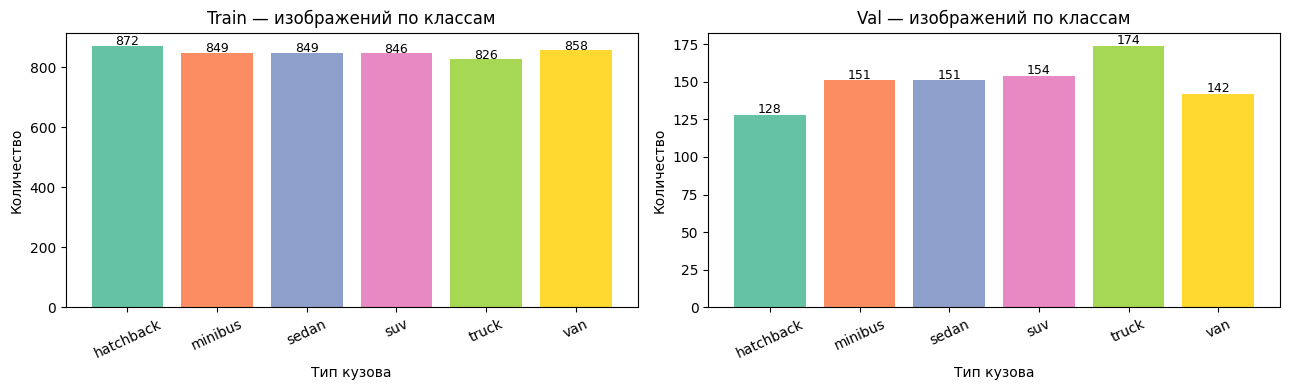

In [8]:
# ── Распределение классов ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette   = sns.color_palette('Set2', len(BODY_LABELS))
for ax, counts, title in [(axes[0], train_counts, 'Train'), (axes[1], val_counts, 'Val')]:
    bars = ax.bar(counts.keys(), counts.values(), color=palette)
    ax.set_title(f'{title} — изображений по классам')
    ax.set_xlabel('Тип кузова'); ax.set_ylabel('Количество')
    ax.tick_params(axis='x', rotation=25)
    for bar, v in zip(bars, counts.values()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_class_distribution.png'), dpi=130, bbox_inches='tight')
plt.show()

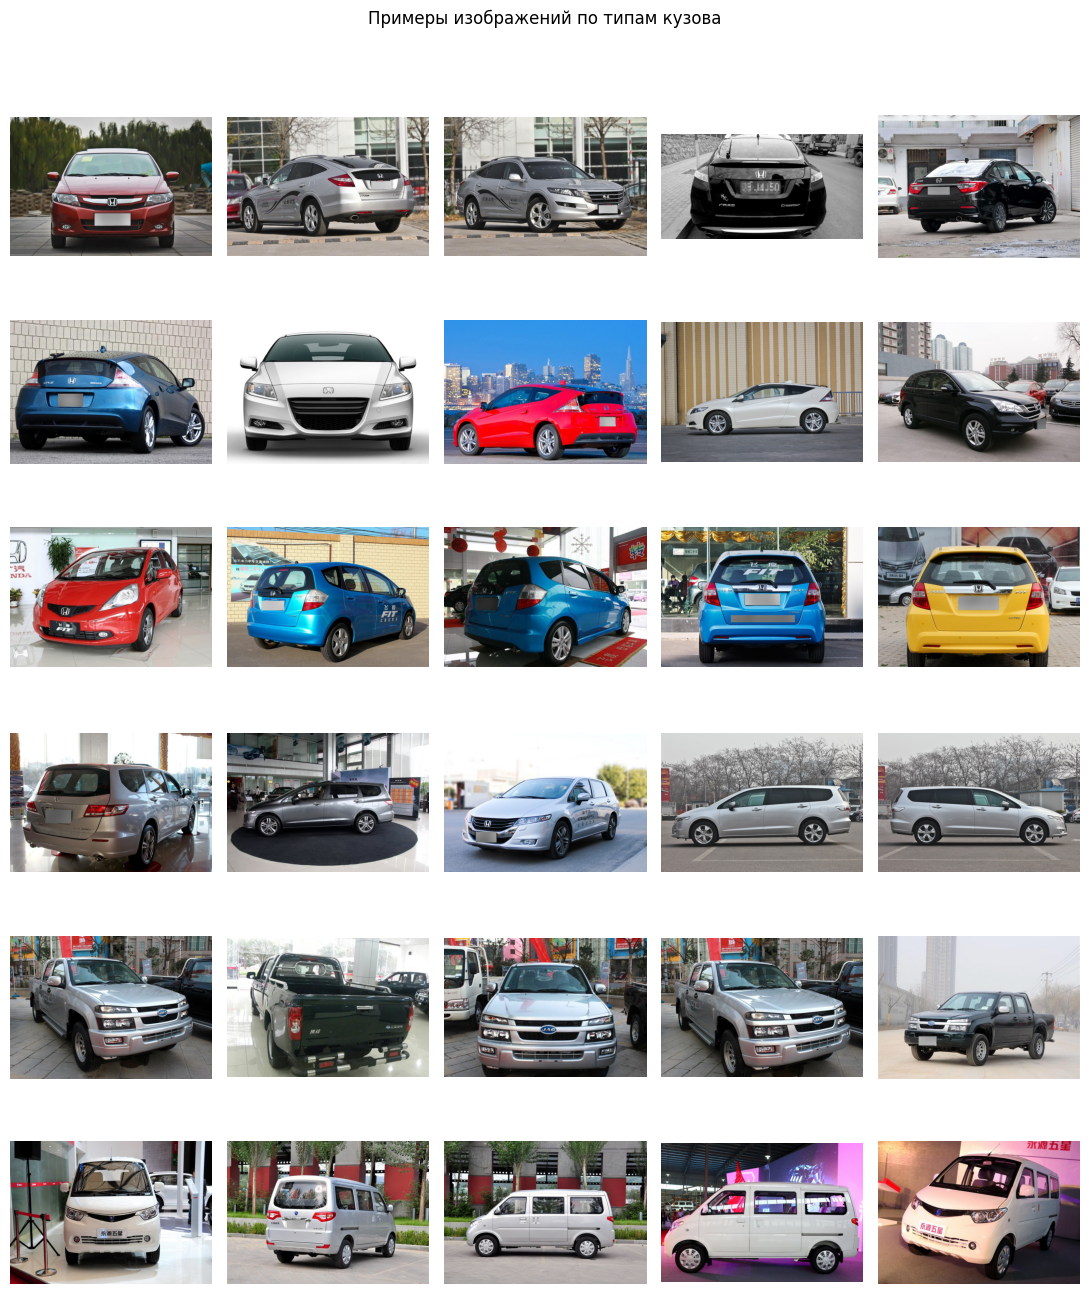

In [9]:
# ── Примеры изображений ───────────────────────────────────────────────────────
n_show = 5
fig, axes = plt.subplots(len(BODY_LABELS), n_show,
                          figsize=(n_show*2.2, len(BODY_LABELS)*2.2))
for row, label in enumerate(BODY_LABELS):
    imgs = sorted((DATA_DIR / 'train' / label).glob('*.jpg'))[:n_show]
    for col, p in enumerate(imgs):
        axes[row][col].imshow(Image.open(p)); axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(label, fontsize=10, rotation=0,
                                       labelpad=55, va='center')
    for col in range(len(imgs), n_show): axes[row][col].axis('off')
plt.suptitle('Примеры изображений по типам кузова', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eda_samples.png'), dpi=120, bbox_inches='tight'); plt.show()

## 3. Fine-tuning ResNet18

**Двухфазное обучение:**
- **Фаза 1** (эпохи 1 → `UNFREEZE_AT`): backbone заморожен, только `fc`
- **Фаза 2** (эпохи `UNFREEZE_AT` → конец): весь backbone, LR × 0.1

In [10]:
TRAIN_TF = T.Compose([
    T.RandomResizedCrop(224, scale=(0.78, 1.0)),    # ↑ нижняя граница: не срезаем силуэт (крыша/багажник)
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),    # только свет; насыщенность/grayscale для типа кузова не нужны
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    T.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])
VAL_TF = T.Compose([
    T.Resize((224,224)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = ImageFolder(DATA_DIR / 'train', transform=TRAIN_TF)
val_ds   = ImageFolder(DATA_DIR / 'val',   transform=VAL_TF)
# num_workers=2 — безопасно с /tmp; pin_memory ускоряет GPU-transfer
_PIN = DEVICE == 'cuda'
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=_PIN)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=_PIN)
print(f'Классы: {train_ds.classes}')
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}')

def build_resnet18(num_classes):
    m = resnet18(weights=ResNet18_Weights.DEFAULT)
    for p in m.parameters(): p.requires_grad = False
    # Dropout перед fc снижает переобучение
    m.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(m.fc.in_features, num_classes),
    )
    return m

model     = build_resnet18(len(BODY_LABELS)).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
print('Модель построена.')

optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)


Классы: ['hatchback', 'minibus', 'sedan', 'suv', 'truck', 'van']
Train: 5100  Val: 900
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 120MB/s]


Модель построена.


In [11]:
def mixup_batch(imgs, labels, alpha=0.4):
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(imgs.size(0), device=imgs.device)
    return lam * imgs + (1 - lam) * imgs[idx], labels, labels[idx], lam


def run_epoch(model, loader, criterion, optimizer=None, mixup_alpha=0.0):
    training = optimizer is not None
    model.train() if training else model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
                if mixup_alpha > 0:
                    imgs, la, lb, lam = mixup_batch(imgs, labels, mixup_alpha)
                    out  = model(imgs)
                    loss = lam * criterion(out, la) + (1 - lam) * criterion(out, lb)
                else:
                    out  = model(imgs)
                    loss = criterion(out, labels)
                loss.backward()
                optimizer.step()
            else:
                out  = model(imgs)
                loss = criterion(out, labels)
            loss_sum += loss.item() * len(labels)
            correct  += (out.argmax(1) == labels).sum().item()
            total    += len(labels)
    return loss_sum / total, correct / total


MIXUP_ALPHA = 0.2   # α=0 отключает mixup; 0.2–0.4 — типичный диапазон

history, best_acc = [], 0.0
no_improve = 0
print(f'Обучение ResNet18 ({EPOCHS} эпох max, device={DEVICE}, patience={PATIENCE}, mixup_alpha={MIXUP_ALPHA})')
print('─' * 65)
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    if epoch == UNFREEZE_AT:
        for name, p in model.named_parameters():
            if any(n in name for n in ['layer3', 'layer4', 'fc']):
                p.requires_grad = True
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR * 0.05,
            weight_decay=WEIGHT_DECAY
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3)
        print(f'  [Epoch {epoch}] Backbone разморожен, lr={LR*0.05:.1e}')

    tl, ta = run_epoch(model, train_loader, criterion, optimizer, MIXUP_ALPHA)
    vl, va = run_epoch(model, val_loader,   criterion)
    scheduler.step(va)
    history.append({'epoch': epoch, 'tl': tl, 'ta': ta, 'vl': vl, 'va': va})
    improved = '✓' if va > best_acc else ' '
    print(f'  Epoch {epoch:2d}/{EPOCHS}  train_loss={tl:.4f}  val_acc={va:.4f} {improved}')
    if va > best_acc:
        best_acc = va
        no_improve = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'  Early stopping на эпохе {epoch} (нет улучшения {PATIENCE} эпох)')
            print(f'Модель → {MODEL_SAVE_PATH}')
            break

print(f'Best val_acc: {best_acc:.4f}  |  {time.time()-t0:.0f}s')
print('─' * 65)

Обучение ResNet18 (40 эпох max, device=cuda, patience=7, mixup_alpha=0.2)
─────────────────────────────────────────────────────────────────
  Epoch  1/40  train_loss=1.8057  val_acc=0.4544 ✓
  Epoch  2/40  train_loss=1.6279  val_acc=0.5256 ✓
  Epoch  3/40  train_loss=1.5832  val_acc=0.5578 ✓
  Epoch  4/40  train_loss=1.5906  val_acc=0.5644 ✓
  Epoch  5/40  train_loss=1.5551  val_acc=0.5244  
  [Epoch 6] Backbone разморожен, lr=5.0e-05
  Epoch  6/40  train_loss=1.4322  val_acc=0.6478 ✓
  Epoch  7/40  train_loss=1.3115  val_acc=0.6956 ✓
  Epoch  8/40  train_loss=1.2513  val_acc=0.7200 ✓
  Epoch  9/40  train_loss=1.1767  val_acc=0.7222 ✓
  Epoch 10/40  train_loss=1.1345  val_acc=0.7311 ✓
  Epoch 11/40  train_loss=1.1204  val_acc=0.7522 ✓
  Epoch 12/40  train_loss=1.0601  val_acc=0.7633 ✓
  Epoch 13/40  train_loss=1.0298  val_acc=0.7722 ✓
  Epoch 14/40  train_loss=0.9856  val_acc=0.7500  
  Epoch 15/40  train_loss=0.9624  val_acc=0.7711  
  Epoch 16/40  train_loss=0.9126  val_acc=0.7811 ✓


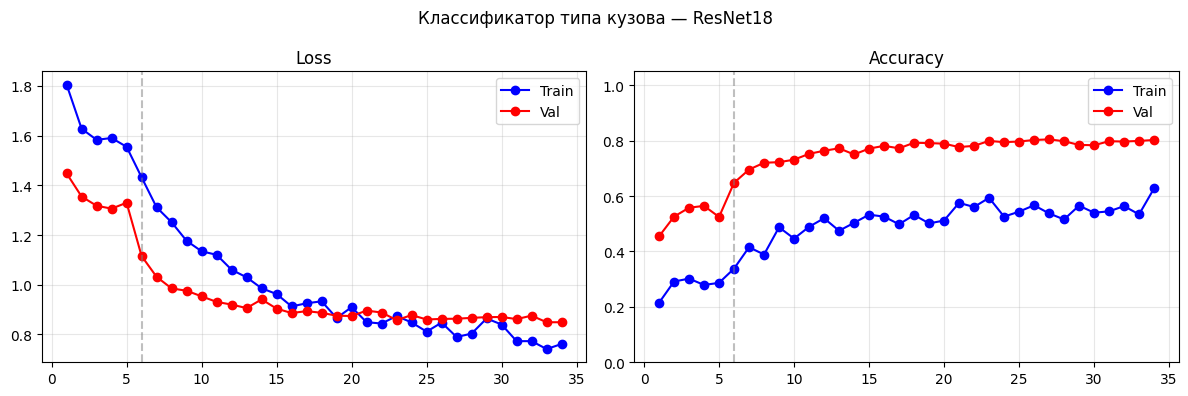

In [12]:
# ── Кривые обучения ───────────────────────────────────────────────────────────
ep = [h['epoch'] for h in history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ep, [h['tl'] for h in history], 'b-o', label='Train')
ax1.plot(ep, [h['vl'] for h in history], 'r-o', label='Val')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.axvline(UNFREEZE_AT, color='gray', linestyle='--', alpha=0.5)
ax2.plot(ep, [h['ta'] for h in history], 'b-o', label='Train')
ax2.plot(ep, [h['va'] for h in history], 'r-o', label='Val')
ax2.set_title('Accuracy'); ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(alpha=0.3)
ax2.axvline(UNFREEZE_AT, color='gray', linestyle='--', alpha=0.5)
plt.suptitle('Классификатор типа кузова — ResNet18')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'training_history.png'), dpi=130, bbox_inches='tight'); plt.show()

## 4. Оценка качества

In [13]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.eval()

# ── TTA: усредняем softmax по оригиналу и горизонтальному отражению (бесплатный прирост) ──
def tta_proba(imgs):
    imgs = imgs.to(DEVICE)
    p1 = torch.softmax(model(imgs), dim=1)
    p2 = torch.softmax(model(torch.flip(imgs, dims=[3])), dim=1)
    return ((p1 + p2) / 2).cpu().numpy()

y_true, y_pred, y_proba = [], [], []
with torch.no_grad():
    for imgs, targets in val_loader:
        probs = tta_proba(imgs)
        y_proba.append(probs)
        y_pred.extend(probs.argmax(1).tolist())
        y_true.extend(targets.numpy().tolist())
y_proba = np.concatenate(y_proba)

acc1 = accuracy_score(y_true, y_pred)
acc3 = top_k_accuracy_score(y_true, y_proba, k=3)
rep  = classification_report(y_true, y_pred, target_names=BODY_LABELS,
                              output_dict=True, zero_division=0)
print(f'Accuracy top-1: {acc1:.4f}')
print(f'Accuracy top-3: {acc3:.4f}')
print()
print(f'{"Класс":12s}  {"Precision":>9}  {"Recall":>6}  {"F1":>6}  {"N":>5}')
print('─' * 48)
for label in BODY_LABELS:
    m = rep.get(label, {})
    print(f'{label:12s}  {m.get("precision",0):9.3f}  {m.get("recall",0):6.3f}  '
          f'{m.get("f1-score",0):6.3f}  {int(m.get("support",0)):5d}')

Accuracy top-1: 0.8056
Accuracy top-3: 0.9689

Класс         Precision  Recall      F1      N
────────────────────────────────────────────────
sedan             0.626   0.562   0.593    128
suv               0.830   0.940   0.882    151
hatchback         0.841   0.768   0.803    151
van               0.745   0.701   0.722    154
truck             0.941   1.000   0.969    174
minibus           0.774   0.796   0.785    142


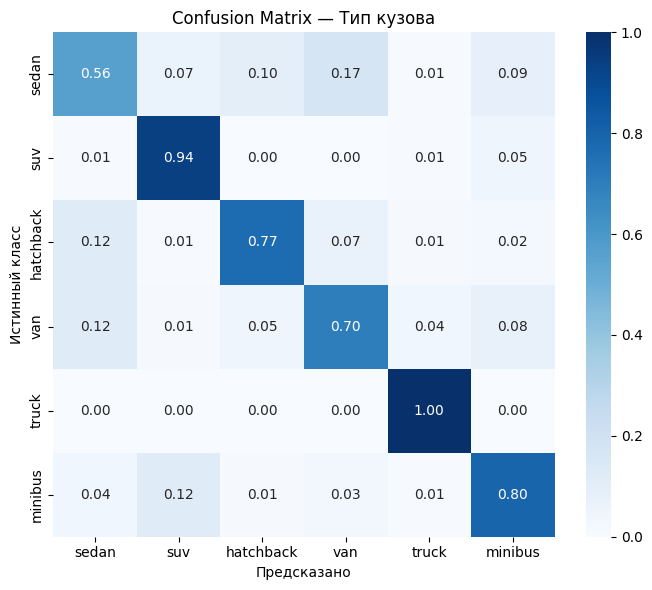

In [14]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / (cm.sum(1, keepdims=True) + 1e-9)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=BODY_LABELS, yticklabels=BODY_LABELS, ax=ax)
ax.set_xlabel('Предсказано'); ax.set_ylabel('Истинный класс')
ax.set_title('Confusion Matrix — Тип кузова')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'confusion_matrix.png'), dpi=150, bbox_inches='tight'); plt.show()

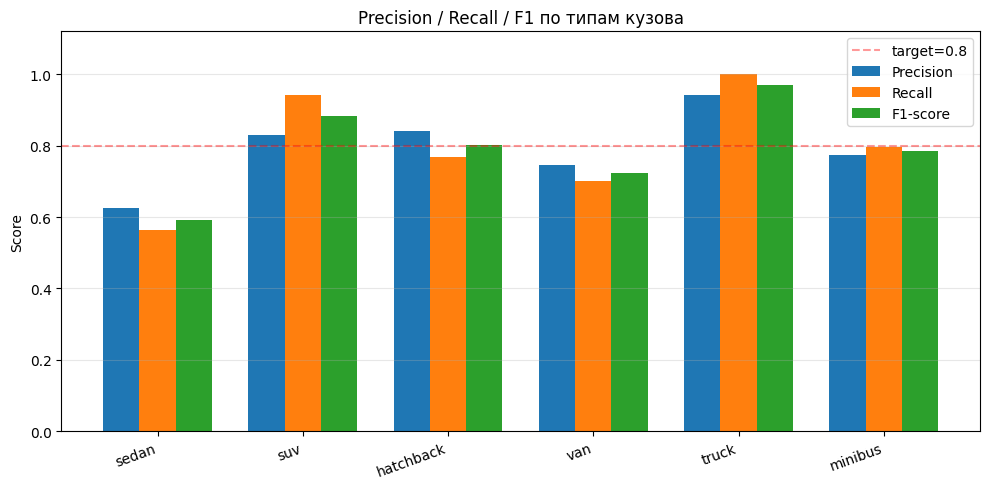

In [15]:
# ── F1 per class ──────────────────────────────────────────────────────────────
metrics_names = ['precision', 'recall', 'f1-score']
data = {m: [rep.get(l,{}).get(m,0) for l in BODY_LABELS] for m in metrics_names}
x, w = np.arange(len(BODY_LABELS)), 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for i, (met, vals) in enumerate(data.items()):
    ax.bar(x + i*w, vals, w, label=met.capitalize())
ax.set_xticks(x + w); ax.set_xticklabels(BODY_LABELS, rotation=20, ha='right')
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 по типам кузова')
ax.axhline(0.8, color='red', linestyle='--', alpha=0.4, label='target=0.8')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'per_class_metrics.png'), dpi=130, bbox_inches='tight'); plt.show()

## 5. Эксперимент: сравнение архитектур (ResNet18 / ResNet50 / EfficientNet-B0)

Сравниваем три архитектуры **в едином протоколе** (feature extraction: backbone заморожен, обучается только классификатор; одинаковые данные, эпохи, оптимизатор) — это изолирует качество предобученного backbone. Задеплоенная ResNet18 (раздел 3, полный двухфазный fine-tuning) приводится отдельно как итоговая модель.


── ResNet18: feature extraction, 15 эпох ──
  epoch  5/15  val_acc=0.5811  best=0.5811
  epoch 10/15  val_acc=0.6156  best=0.6156
  epoch 15/15  val_acc=0.5889  best=0.6156

── ResNet50: feature extraction, 15 эпох ──
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


  epoch  5/15  val_acc=0.6344  best=0.6344
  epoch 10/15  val_acc=0.6478  best=0.6656
  epoch 15/15  val_acc=0.6578  best=0.6656

── EfficientNet-B0: feature extraction, 15 эпох ──
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 157MB/s]


  epoch  5/15  val_acc=0.6044  best=0.6056
  epoch 10/15  val_acc=0.6089  best=0.6256
  epoch 15/15  val_acc=0.6367  best=0.6367

── Сравнение архитектур (единый протокол: feature extraction) ──
         Модель  Params, M  FLOPS, G  Test Acc  FPS (T4)  .pth, MB
       ResNet18       11.2      1.80    0.6156     330.8      44.7
       ResNet50       23.5      4.10    0.6656     180.2      94.1
EfficientNet-B0        4.0      0.39    0.6367     134.1      16.1


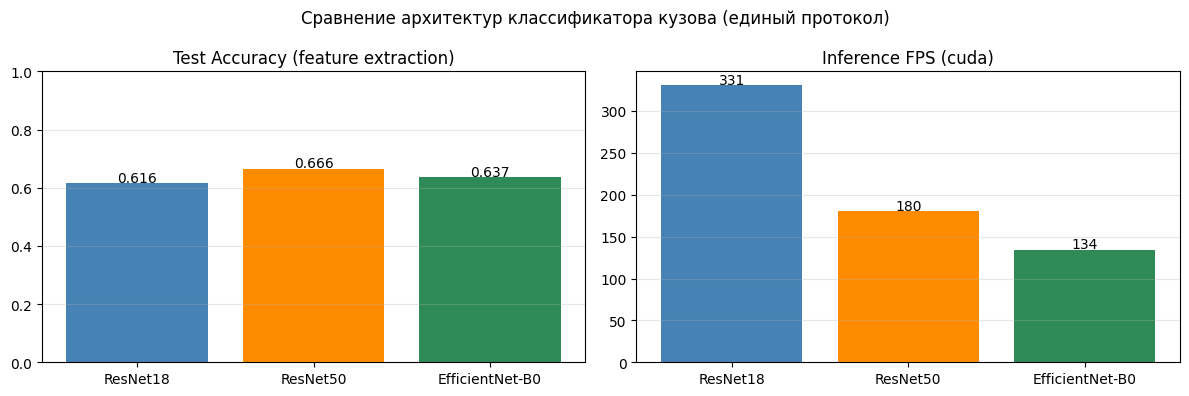

In [16]:
# ── Сравнение архитектур: ResNet18 vs ResNet50 vs EfficientNet-B0 ─────
# Единый протокол для всех: feature extraction (обучается только классификатор,
# backbone заморожен), одинаковые данные/эпохи/оптимизатор — изолирует качество backbone.
import pandas as pd
from torchvision.models import (resnet50, ResNet50_Weights,
                                 efficientnet_b0, EfficientNet_B0_Weights)

CMP_EPOCHS = 15   # одинаково для всех архитектур

def _fe_resnet18():
    m = resnet18(weights=ResNet18_Weights.DEFAULT)
    for p in m.parameters(): p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, len(BODY_LABELS))
    return m, m.fc.parameters()

def _fe_resnet50():
    m = resnet50(weights=ResNet50_Weights.DEFAULT)
    for p in m.parameters(): p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, len(BODY_LABELS))
    return m, m.fc.parameters()

def _fe_effb0():
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    for p in m.parameters(): p.requires_grad = False
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(BODY_LABELS))
    return m, m.classifier.parameters()

_GFLOPS = {'ResNet18': 1.8, 'ResNet50': 4.1, 'EfficientNet-B0': 0.39}  # @224, справочно

def _fps(model, n=50):
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
    with torch.no_grad():
        for _ in range(5): model(dummy)            # warm-up
        t0 = time.time()
        for _ in range(n): model(dummy)
    return round(n / (time.time() - t0), 1)

cmp_rows = []
for name, builder in [('ResNet18', _fe_resnet18),
                      ('ResNet50', _fe_resnet50),
                      ('EfficientNet-B0', _fe_effb0)]:
    print(f'\n── {name}: feature extraction, {CMP_EPOCHS} эпох ──')
    m, head = builder()
    m = m.to(DEVICE)
    opt = torch.optim.Adam(head, lr=LR)
    best = 0.0
    for ep in range(1, CMP_EPOCHS + 1):
        run_epoch(m, train_loader, criterion, opt)
        _, va = run_epoch(m, val_loader, criterion)
        best = max(best, va)
        if ep % 5 == 0 or ep == CMP_EPOCHS:
            print(f'  epoch {ep:2d}/{CMP_EPOCHS}  val_acc={va:.4f}  best={best:.4f}')
    n_params = sum(p.numel() for p in m.parameters()) / 1e6
    cmp_rows.append({'Модель': name,
                     'Params, M': round(n_params, 1),
                     'FLOPS, G': _GFLOPS[name],
                     'Test Acc': round(best, 4),
                     'FPS (T4)': _fps(m),
                     '.pth, MB': round(n_params * 4, 1)})

df_arch = pd.DataFrame(cmp_rows)
print('\n── Сравнение архитектур (единый протокол: feature extraction) ──')
print(df_arch.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'darkorange', 'seagreen']
ax1.bar(df_arch['Модель'], df_arch['Test Acc'], color=colors)
for i, v in enumerate(df_arch['Test Acc']): ax1.text(i, v + 0.005, f'{v:.3f}', ha='center')
ax1.set_ylim(0, 1.0); ax1.set_title('Test Accuracy (feature extraction)'); ax1.grid(axis='y', alpha=0.3)
ax2.bar(df_arch['Модель'], df_arch['FPS (T4)'], color=colors)
for i, v in enumerate(df_arch['FPS (T4)']): ax2.text(i, v + 2, f'{v:.0f}', ha='center')
ax2.set_title(f'Inference FPS ({DEVICE})'); ax2.grid(axis='y', alpha=0.3)
plt.suptitle('Сравнение архитектур классификатора кузова (единый протокол)')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'model_comparison.png'), dpi=130, bbox_inches='tight'); plt.show()


In [17]:
# ── Итог ───────────────────────────────────────────────
results = {
    'task': 'body_classification', 'device': DEVICE,
    'epochs': EPOCHS, 'num_classes': len(BODY_LABELS), 'classes': BODY_LABELS,
    'accuracy_top1': round(acc1, 4), 'accuracy_top3': round(acc3, 4),
    'arch_comparison': df_arch.to_dict(orient='records'),
    'history': history,
}
with open(OUTPUT_DIR / 'results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print('═' * 55)
print(f'  Классификатор кузова — ИТОГ')
print(f'  Accuracy top-1 (deployed ResNet18): {acc1:.4f}')
print(f'  Accuracy top-3:                     {acc3:.4f}')
print(f'  Модель:                             {MODEL_SAVE_PATH}')
print('  Сравнение архитектур (feature extraction):')
for r in df_arch.to_dict(orient='records'):
    print(f'    {r["Модель"]:16s} acc={r["Test Acc"]:.4f}  fps={r["FPS (T4)"]}')
print('═' * 55)

if IN_COLAB:
    import zipfile
    from google.colab import files
    with zipfile.ZipFile('results_03_body.zip', 'w') as zf:
        for p in OUTPUT_DIR.glob('*'): zf.write(p, p.name)
        zf.write(MODEL_SAVE_PATH, MODEL_SAVE_PATH.name)
    files.download('results_03_body.zip')


═══════════════════════════════════════════════════════
  Классификатор кузова — ИТОГ
  Accuracy top-1 (deployed ResNet18): 0.8056
  Accuracy top-3:                     0.9689
  Модель:                             /content/drive/MyDrive/diploma/models/body_resnet18.pth
  Сравнение архитектур (feature extraction):
    ResNet18         acc=0.6156  fps=330.8
    ResNet50         acc=0.6656  fps=180.2
    EfficientNet-B0  acc=0.6367  fps=134.1
═══════════════════════════════════════════════════════


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>